In [1]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

from network import FCN, Layer
from metrics import confusion_matrix, accuracy, plot_losses, summary

I0000 00:00:1785007421.642691   75771 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785007421.643177   75771 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785007421.677154   75771 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785007422.702388   75771 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
def show_digit(X, y, index):
    plt.imshow(X[index].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y[index])}")
    plt.axis('off')
    plt.show()

In [3]:
def one_hot(y, classes=10):
    encoded = np.zeros((len(y), classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

FCN initialized


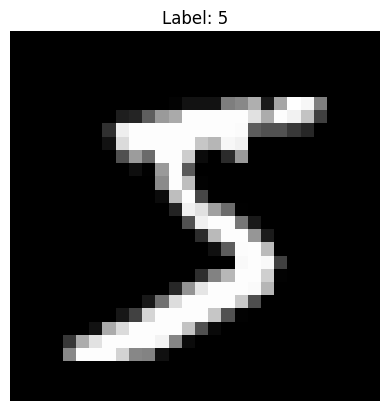

In [4]:
# initialize network with 2 hidden layers
network = FCN([
    Layer(784),
    Layer(128, 'relu'),
    Layer(64, 'relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy")

# load mnist data and split into train and test partitions
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
y_train_full = one_hot(y_train_full)
y_test = one_hot(y_test)

# flatten each image from (28x28) to 784, then normalise to [0,1]
X_train_full = X_train_full.reshape(60000, 784) / 255.0
X_test  = X_test.reshape(10000, 784)  / 255.0

X_train, y_train = X_train_full[:50000], y_train_full[:50000]
X_val, y_val = X_train_full[50000:], y_train_full[50000:]



# test show a digit
show_digit(X_train, y_train, 0)



Epoch 1/3 - Loss: 0.4583
Validation Loss: 0.1430
Epoch 2/3 - Loss: 0.1237
Validation Loss: 0.1335
Epoch 3/3 - Loss: 0.0835
Validation Loss: 0.1284


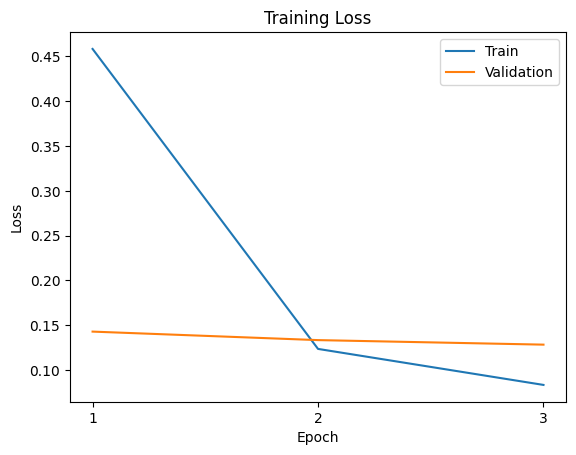

Test Accuracy: 96.00%


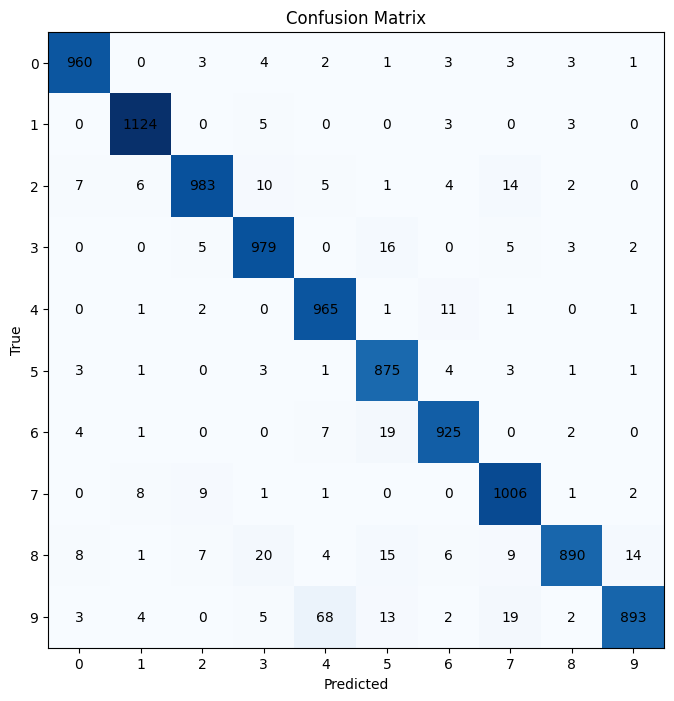

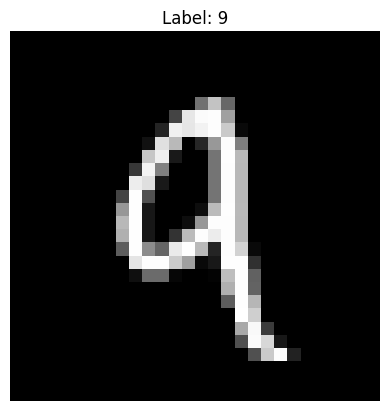

[0.0002 0.     0.0013 0.0109 0.0081 0.0013 0.     0.0002 0.0048 0.9733]


In [5]:
losses = network.train(X_train, y_train, X_val, y_val, epochs=3)

# display some metrics
plot_losses(losses)
summary(network, X_test, y_test)

show_digit(X_test, y_test, 125)
np.set_printoptions(precision=4, suppress=True)
print(network.predict(X_test[125]))